# Question 01

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load runway image in grayscale
f = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found. Check the path.'
print('Image shape:', f.shape)
print('Image dtype:', f.dtype)

Image shape: (769, 765)
Image dtype: uint8


### (a) Gamma correction with γ = 0.5.

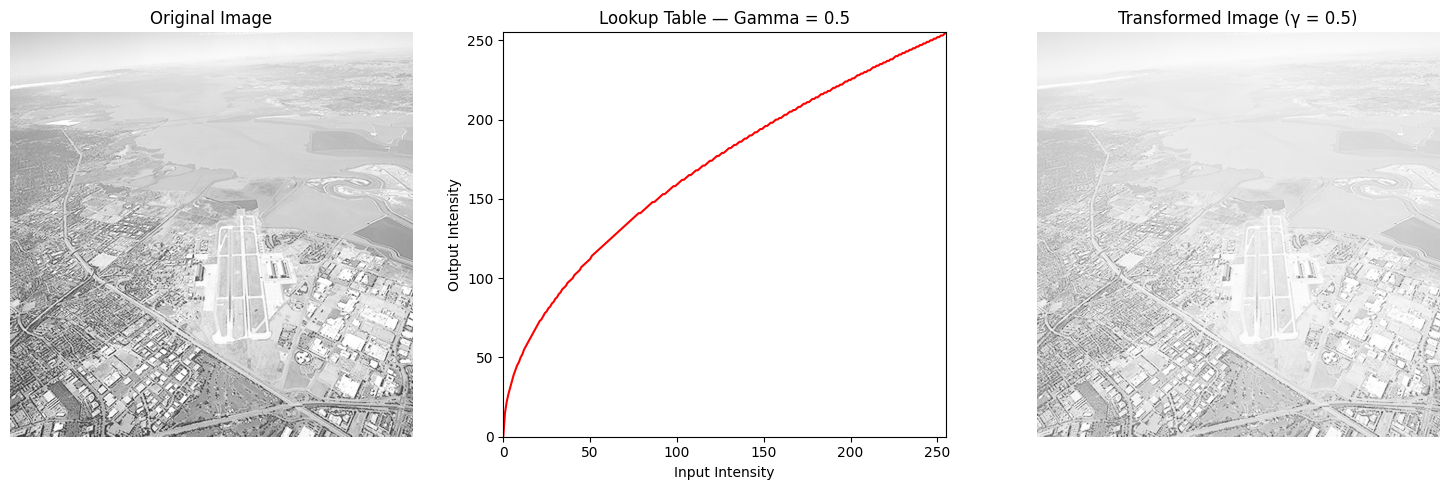

In [ ]:
gamma = 0.5

t = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

g_gamma5 = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title('Lookup Table — Gamma = 0.5')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_gamma5, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Image (γ = 0.5)')
ax[0].axis('off')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Transformed image brighter than original image. The LUT curve bends upward, meaning dark pixel values are mapped to much higher output values.

### (b) Gamma correction with γ = 2.

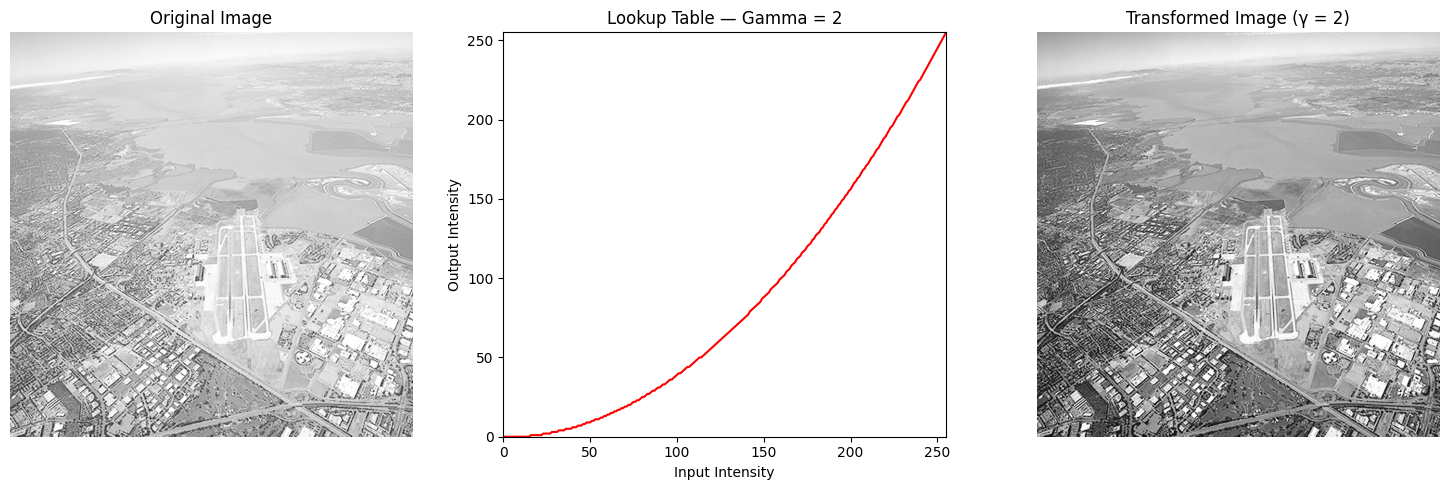

In [7]:
gamma = 2

t = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

g_gamma2 = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title('Lookup Table — Gamma = 2')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_gamma2, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Image (γ = 2)')
ax[2].axis('off')
plt.tight_layout()
plt.show()

Transformed image darker than original image. The LUT curve bends downward, compressing mid-tone and bright pixel values toward lower intensities.

### (c) Contrast Stretching (linear piecewise transformation)

LUT length: 256


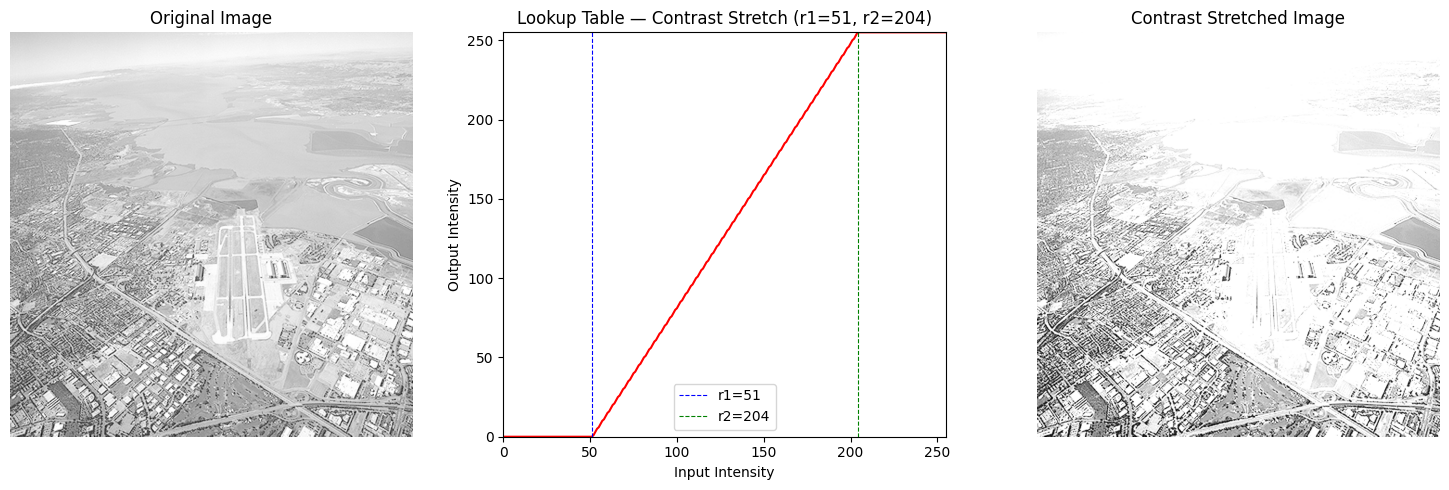

In [8]:
# Convert normalized r1, r2 to 0-255 pixel range
r1 = int(0.2 * 255)  # 51
r2 = int(0.8 * 255)  # 204

# Build LUT in 3 segments
t1 = np.zeros(r1, dtype=np.uint8)                        # 0.......50  --> 0
t2 = np.linspace(0, 255, r2 - r1 + 1).astype(np.uint8)  # 51.......204 --> 0.......255
t3 = np.full(255 - r2, 255, dtype=np.uint8)              # 205.......255 --> 255

t = np.concatenate((t1, t2, t3))
print('LUT length:', len(t))  # 256

g_contrast = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title(f'Lookup Table — Contrast Stretch (r1={r1}, r2={r2})')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].axvline(x=r1, color='blue', linestyle='--', linewidth=0.8, label=f'r1={r1}')
ax[1].axvline(x=r2, color='green', linestyle='--', linewidth=0.8, label=f'r2={r2}')
ax[1].legend()
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_contrast, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Contrast Stretched Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()

Pixels below intensity 51 are clipped to 0 (pure black) and pixels above 204 are clipped to 255 (pure white). The middle range [51, 204] is linearly stretched across the full [0, 255] range. This maximizes contrast in the mid-tones of the runway image, making features within that intensity range more visible , but it reduces detail in the very dark and very bright areas.

# Question 02

### (a) Gamma Correction to the L plane in the L*a*b* color space

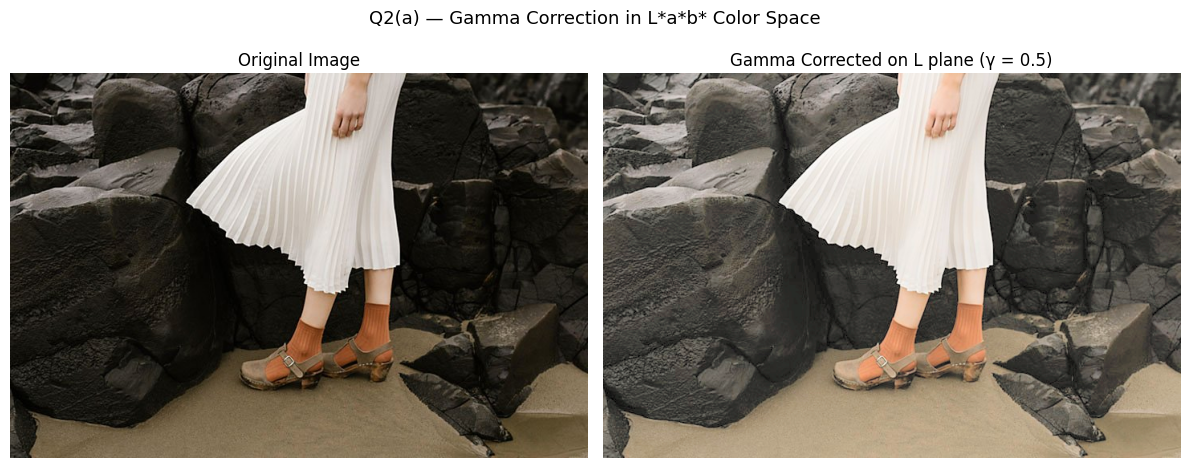

Gamma value used: γ = 0.5


In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the color image
img = cv.imread('a1images/highlights_and_shadows.jpg')
assert img is not None, 'Image not found. Check the path.'

# Convert BGR to L*a*b* color space
img_lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

# Split into L, a, b channels
L, a, b = cv.split(img_lab)

# Apply gamma correction to L channel using LUT
gamma = 0.5 # chosen to brighten the image (dark areas lifted)
t = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
L_corrected = t[L]

# Merge corrected L with original a, b channels
img_lab_corrected = cv.merge([L_corrected, a, b])

# Convert back to BGR for display
img_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
ax[1].set_title(f'Gamma Corrected on L plane (γ = {gamma})')
ax[1].axis('off')
plt.suptitle('Q2(a) — Gamma Correction in L*a*b* Color Space', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Gamma value used: γ = {gamma}')


Gamma correction with γ = 0.5 was applied to the L (Lightness) channel in the L*a*b* color space. Since γ < 1, the Lookup Table curve bends upward,mapping dark pixel values to higher output values, making the image visibly brighter. The a* and b* channels were kept unchanged, so the color of the image is not affected, only the brightness.

### (b) Histograms

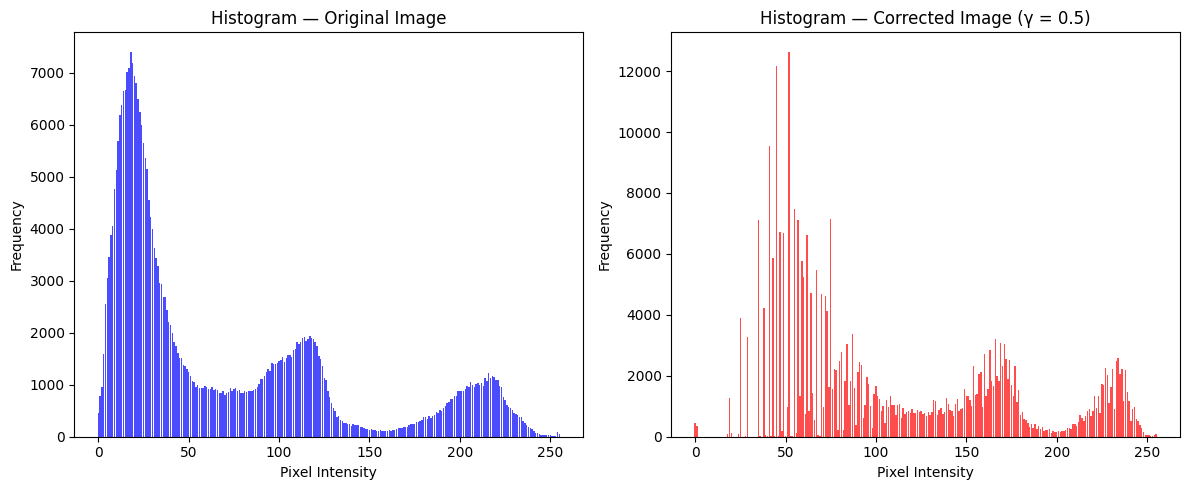

In [13]:
hist_original = np.bincount(img_gray.ravel(), minlength=256)
hist_corrected = np.bincount(img_corrected_gray.ravel(), minlength=256)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(range(256), hist_original, color='blue', alpha=0.7)
ax[0].set_title('Histogram — Original Image')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')
ax[1].bar(range(256), hist_corrected, color='red', alpha=0.7)
ax[1].set_title(f'Histogram — Corrected Image (γ = {gamma})')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


The original image histogram shows pixel counts concentrated at low intensities (peak around 15–20), indicating a dark image. After gamma  correction (γ = 0.5), the histogram shifts toward higher intensity values (peak around 50), confirming the image has been brightened.

# Question 03

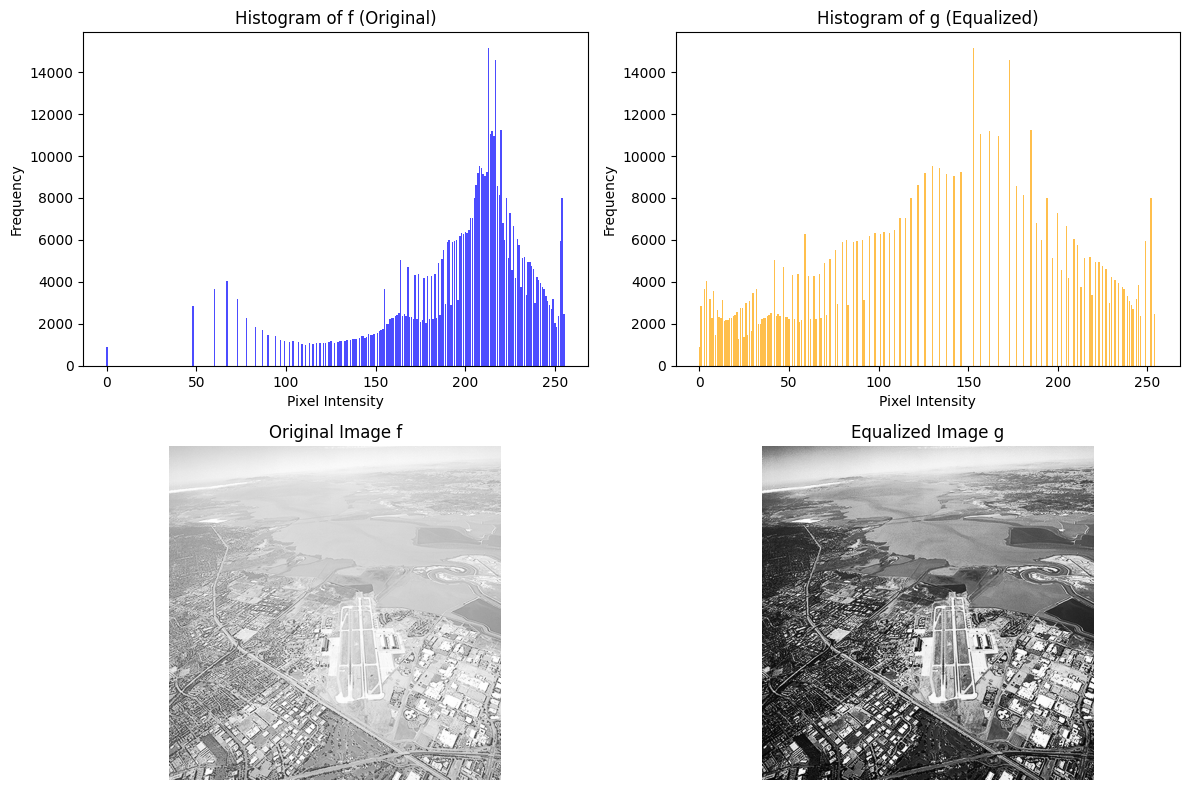

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def equalize_hist(f):
    M, N = f.shape[0], f.shape[1]
    L = 255  # number of gray levels
    hist_f = np.histogram(f.ravel(), bins=256, range=(0, 255))[0]
    cum_hist_f = np.cumsum(hist_f)
    t = np.array([(L - 1) / (M * N) * cum_hist_f[k] for k in range(256)], dtype=np.uint8)
    g = t[f]
    return g

# Load runway image in grayscale
f = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found. Check the path.'

# Apply histogram equalization using the function
g = equalize_hist(f)

# Compute histograms for display
hist_f = np.histogram(f.ravel(), bins=256, range=(0, 255))[0]
hist_g = np.histogram(g.ravel(), bins=256, range=(0, 255))[0]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].bar(range(256), hist_f, color='blue', alpha=0.7)
ax[0, 0].set_title('Histogram of f (Original)')
ax[0, 0].set_xlabel('Pixel Intensity')
ax[0, 0].set_ylabel('Frequency')
ax[0, 1].bar(range(256), hist_g, color='orange', alpha=0.7)
ax[0, 1].set_title('Histogram of g (Equalized)')
ax[0, 1].set_xlabel('Pixel Intensity')
ax[0, 1].set_ylabel('Frequency')
ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title('Original Image f')
ax[1, 0].axis('off')
ax[1, 1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Equalized Image g')
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()



The original runway image histogram is concentrated at high intensities (peak around 213), indicating a bright, hazy image. After histogram equalization, the pixel intensities are redistributed more uniformly across the full range (0–255). This enhances contrast and helps reveal details that were previously lost or less visible, especially in overly bright regions. The equalized image appears darker overall but with significantly improved contrast and visible detail.

# Question 04

# Question 04

### (a) Otsu Thresholding : Binary mask for the foreground comprising the woman and the room

Otsu threshold value: 101


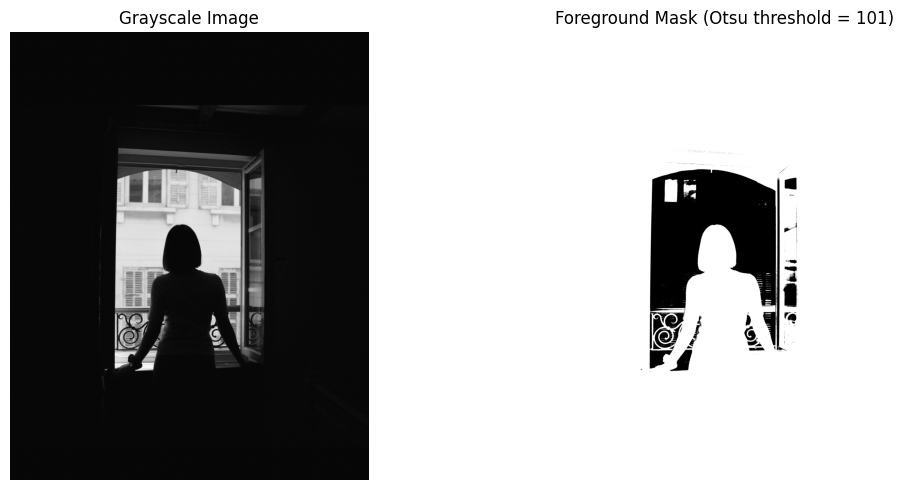

In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('woman_standing.jpg')
assert img is not None, 'Image not found.'

f = cv.cvtColor(img, cv.COLOR_BGR2GRAY)# Convert to grayscale
ret, mask = cv.threshold(f, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)# Otsu thresholding : dark pixels (woman + room) = 255 (foreground), bright pixels (window/sky) = 0 (background)
print(f'Otsu threshold value: {int(ret)}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Grayscale Image')
ax[0].axis('off')
ax[1].imshow(mask, cmap='gray', vmin=0, vmax=255)
ax[1].set_title(f'Foreground Mask (Otsu threshold = {int(ret)})')
ax[1].axis('off')
plt.tight_layout()
plt.show()


Otsu's method automatically finds the optimal threshold value of 101 that separates the bright background (window and sky outside) from the darker foreground (woman and room interior). Pixels below the threshold are assigned white (255) and pixels above are assigned black (0), producing a binary mask where the woman and the room appear as white (foreground) and the bright window region appears as black (background).

### (b) Histogram Equalization only for the Foreground Region

Number of foreground pixels: 24982364


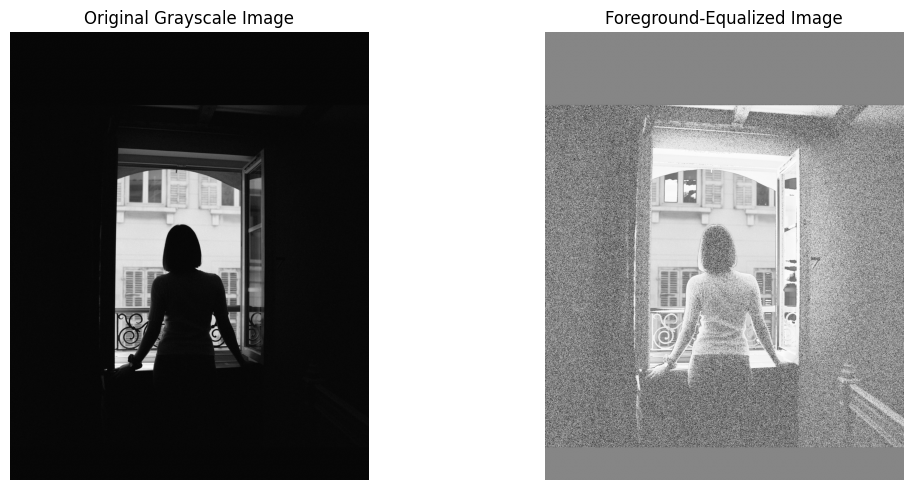

In [30]:
fg_pixels = f[mask == 255] # Extract foreground pixel values
N_fg = fg_pixels.shape[0]  # total foreground pixels
print(f'Number of foreground pixels: {N_fg}')
L = 255

hist_fg = np.histogram(fg_pixels, bins=256, range=(0, 255))[0]
cum_hist_fg = np.cumsum(hist_fg)

t = np.array([(L - 1) / N_fg * cum_hist_fg[k] for k in range(256)], dtype=np.uint8) # histogram equalization formula

g = f.copy() # Apply LUT only to foreground pixels
g[mask == 255] = t[f[mask == 255]]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Grayscale Image')
ax[0].axis('off')
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Foreground-Equalized Image')
ax[1].axis('off')
plt.tight_layout()
plt.show()


By applying histogram equalization only to the foreground (woman and room), the contrast within the dark interior region is stretched across the full intensity range. This reveals hidden features such as the textures on the walls, details in the woman's clothing, and objects in the room that were previously too dark to see.

# Question 05

### (a) Normalized 5×5 Gaussian kernel for σ = 2

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

h_size = 2
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

sigma = 2
g = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g = g / np.sum(g)

print(f'5×5 Normalized Gaussian Kernel (σ=2): \n',g)

5×5 Normalized Gaussian Kernel (σ=2): 
 [[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


### (b) 51×51 computed Gaussian kernel 3D surface plot

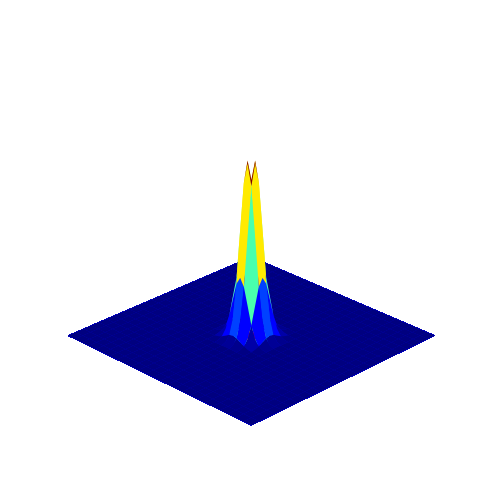

In [47]:
h_size = 25  # 51×51 kernel: ranges from -25 to +25
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

sigma = 2
g_51 = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g_51 = g_51 / np.sum(g_51)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, g_51, cmap='jet', rstride=2, cstride=2, linewidth=0.1, antialiased=True)
ax.contourf(X, Y, g_51, zdir='z', offset=g_51.min(), cmap='jet')
ax.set_axis_off()
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()


### (c) Gaussian smoothing : Apply manually computed 5×5 Gaussian kernel from part (a)

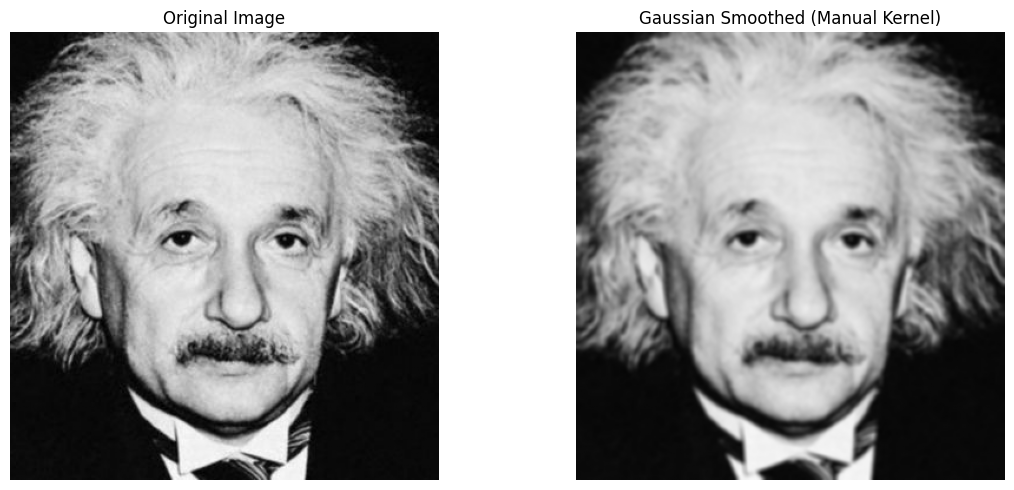

In [51]:
import cv2 as cv

f = cv.imread('a1images/einstein.png', cv.IMREAD_GRAYSCALE).astype(np.float32)
assert f is not None, 'Image not found.'

blurred_manual = cv.filter2D(f, -1, g)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(blurred_manual, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gaussian Smoothed (Manual Kernel)')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### (d) Gaussian smoothing : Use OpenCV built-in cv.GaussianBlur 

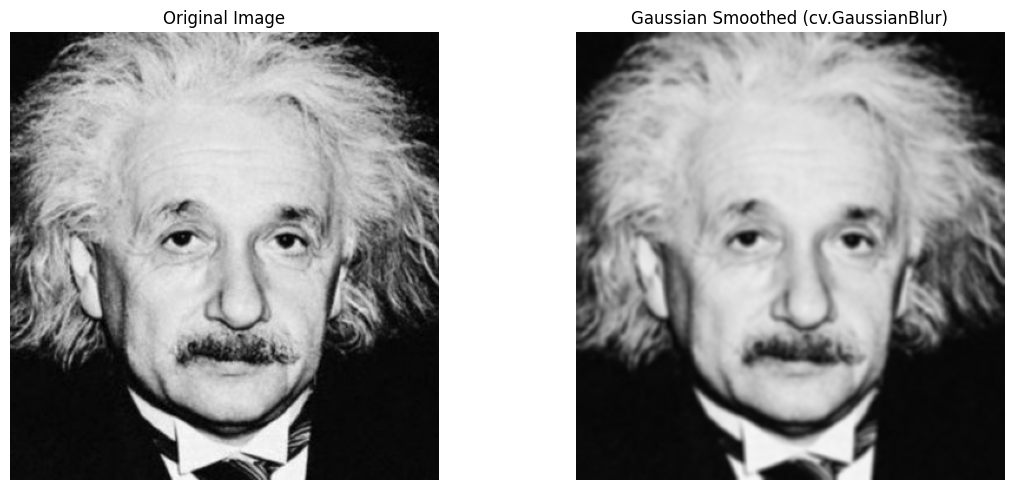

In [52]:
blurred_cv = cv.GaussianBlur(f, (5, 5), 2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(blurred_cv, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gaussian Smoothed (cv.GaussianBlur)')
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Question 06